In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import os
import time
from mpl_toolkits.mplot3d import Axes3D 
import scipy
import sys

In [2]:
import gymnasium
from gymnasium import spaces

In [3]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common import results_plotter
import autograd, autograd.core, autograd.extend, autograd.tracer  
import autograd.numpy as anp 
from deap import base
from deap import creator
from deap import tools
import random
import seaborn as sns
import gudhi as gd

In [4]:
sys.path.append('../../../../../../ocean_intella/ocean_intella/pipelay_profile_optimization/')

In [5]:
import elitism

In [6]:
x0, y0 = 20, 20

### Finite Element Model

In [7]:
class ObjectView(object):
    def __init__(self, d): self.__dict__ = d
    
def get_args(normals, forces, density=1e-4):  # Manage the problem setup parameters
    width = normals.shape[0] - 1
    height = normals.shape[1] - 1
    fixdofs = np.flatnonzero(normals.ravel())
    alldofs = np.arange(2 * (width + 1) * (height + 1))
    freedofs = np.sort(list(set(alldofs) - set(fixdofs)))
    params = {
      # material properties
      'young': 1, 'young_min': 1e-9, 'poisson': 0.3, 'g': 0,
      # constraints
      'density': density, 'xmin': 0.001, 'xmax': 1.0,
      # input parameters
      'nelx': width, 'nely': height, 'mask': 1, 'penal': 3.0, 'filter_width': 1,
      'freedofs': freedofs, 'fixdofs': fixdofs, 'forces': forces.ravel(),
      # optimization parameters
      'opt_steps': 80, 'print_every': 10}
#     print(params)
    return ObjectView(params)

def mbb_beam(width=y0, height=x0, density=1e-4, y=1, x=0, rd=0):  # textbook beam example
    normals = np.zeros((width + 1, height + 1, 2))
    normals[0, 0, x] = 1
    normals[0, 0, y] = 1
    normals[0, -1, x] = 1
    normals[0, -1, y] = 1
    forces = np.zeros((width + 1, height + 1, 2))
    forces[-1, rd, y] = 1
    return normals, forces, density

In [8]:
def young_modulus(x, e_0, e_min, p=3):
    return e_min + x ** p * (e_0 - e_min)

def physical_density(x, args, volume_contraint=False, use_filter=True):
    x = args.mask * x.reshape(args.nely, args.nelx)  # reshape from 1D to 2D
    return gaussian_filter(x, args.filter_width) if use_filter else x  # maybe filter

def mean_density(x, args, volume_contraint=False, use_filter=True):
    return anp.mean(physical_density(x, args, volume_contraint, use_filter)) / anp.mean(args.mask)

In [9]:
def objective(x, args, volume_contraint=False, use_filter=True):
    kwargs = dict(penal=args.penal, e_min=args.young_min, e_0=args.young)
    x_phys = physical_density(x, args, volume_contraint=volume_contraint, use_filter=use_filter)
    ke     = get_stiffness_matrix(args.young, args.poisson)  # stiffness matrix
    u      = displace(x_phys, ke, args.forces, args.freedofs, args.fixdofs, **kwargs)
    c      = compliance(x_phys, u, ke, **kwargs)
    return c

In [10]:
def gaussian_filter(x, width): # 2D gaussian blur/filter
    return scipy.ndimage.gaussian_filter(x, width, mode='reflect')

def _gaussian_filter_vjp(ans, x, width): # gives the gradient of orig. function w.r.t. x
    del ans, x  # unused
    return lambda g: gaussian_filter(g, width)

In [11]:
def compliance(x_phys, u, ke, *, penal=3, e_min=1e-9, e_0=1):
    nely, nelx = x_phys.shape
    ely, elx = anp.meshgrid(range(nely), range(nelx))  # x, y coords for the index map

    n1 = (nely+1)*(elx+0) + (ely+0)  # nodes
    n2 = (nely+1)*(elx+1) + (ely+0)
    n3 = (nely+1)*(elx+1) + (ely+1)
    n4 = (nely+1)*(elx+0) + (ely+1)
    all_ixs = anp.array([2*n1, 2*n1+1, 2*n2, 2*n2+1, 2*n3, 2*n3+1, 2*n4, 2*n4+1])
    u_selected = u[all_ixs]  # select from u matrix

    ke_u = anp.einsum('ij,jkl->ikl', ke, u_selected)  # compute x^penal * U.T @ ke @ U
    ce = anp.einsum('ijk,ijk->jk', u_selected, ke_u)
    C = young_modulus(x_phys, e_0, e_min, p=penal) * ce.T
    return anp.sum(C)

def get_stiffness_matrix(e, nu):  # e=young's modulus, nu=poisson coefficient
    k = anp.array([1/2-nu/6, 1/8+nu/8, -1/4-nu/12, -1/8+3*nu/8,
                -1/4+nu/12, -1/8-nu/8, nu/6, 1/8-3*nu/8])
    return e/(1-nu**2)*anp.array([[k[0], k[1], k[2], k[3], k[4], k[5], k[6], k[7]],
                               [k[1], k[0], k[7], k[6], k[5], k[4], k[3], k[2]],
                               [k[2], k[7], k[0], k[5], k[6], k[3], k[4], k[1]],
                               [k[3], k[6], k[5], k[0], k[7], k[2], k[1], k[4]],
                               [k[4], k[5], k[6], k[7], k[0], k[1], k[2], k[3]],
                               [k[5], k[4], k[3], k[2], k[1], k[0], k[7], k[6]],
                               [k[6], k[3], k[4], k[1], k[2], k[7], k[0], k[5]],
                               [k[7], k[2], k[1], k[4], k[3], k[6], k[5], k[0]]])

In [12]:
def get_k(stiffness, ke):
    # Constructs sparse stiffness matrix k (used in the displace fn)
    # First, get position of the nodes of each element in the stiffness matrix
    nely, nelx = stiffness.shape
    ely, elx = anp.meshgrid(range(nely), range(nelx))  # x, y coords
    ely, elx = ely.reshape(-1, 1), elx.reshape(-1, 1)

    n1 = (nely+1)*(elx+0) + (ely+0)
    n2 = (nely+1)*(elx+1) + (ely+0)
    n3 = (nely+1)*(elx+1) + (ely+1)
    n4 = (nely+1)*(elx+0) + (ely+1)
    edof = anp.array([2*n1, 2*n1+1, 2*n2, 2*n2+1, 2*n3, 2*n3+1, 2*n4, 2*n4+1])
    edof = edof.T[0]
    x_list = anp.repeat(edof, 8)  # flat list pointer of each node in an element
    y_list = anp.tile(edof, 8).flatten()  # flat list pointer of each node in elem

    # make the global stiffness matrix K
    kd = stiffness.T.reshape(nelx*nely, 1, 1)
    value_list = (kd * anp.tile(ke, kd.shape)).flatten()
    return value_list, y_list, x_list

def displace(x_phys, ke, forces, freedofs, fixdofs, *, penal=3, e_min=1e-9, e_0=1):
    # Displaces the load x using finite element techniques (solve_coo=most of runtime)
    stiffness = young_modulus(x_phys, e_0, e_min, p=penal)
    k_entries, k_ylist, k_xlist = get_k(stiffness, ke)

    index_map, keep, indices = _get_dof_indices(freedofs, fixdofs, k_ylist, k_xlist)

    u_nonzero = solve_coo(k_entries[keep], indices, forces[freedofs], sym_pos=True)
    u_values = anp.concatenate([u_nonzero, anp.zeros(len(fixdofs))])
    return u_values[index_map]

In [13]:
def _get_dof_indices(freedofs, fixdofs, k_xlist, k_ylist):
    index_map = inverse_permutation(anp.concatenate([freedofs, fixdofs]))
    keep = anp.isin(k_xlist, freedofs) & anp.isin(k_ylist, freedofs)
    # Now we index an indexing array that is being indexed by the indices of k
    i = index_map[k_ylist][keep]
    j = index_map[k_xlist][keep]
    return index_map, keep, anp.stack([i, j])

def inverse_permutation(indices):  # reverses an index operation
    inverse_perm = np.zeros(len(indices), dtype=anp.int64)
    inverse_perm[indices] = np.arange(len(indices), dtype=anp.int64)
    return inverse_perm

In [14]:
def _get_solver(a_entries, a_indices, size, sym_pos):
    # a is (usu.) symmetric positive; could solve 2x faster w/sksparse.cholmod.cholesky(a).solve_A
    a = scipy.sparse.coo_matrix((a_entries, a_indices), shape=(size,)*2).tocsc()
    return scipy.sparse.linalg.splu(a).solve


def solve_coo(a_entries, a_indices, b, sym_pos=False):
    solver = _get_solver(a_entries, a_indices, b.size, sym_pos)
    return solver(b)

def grad_solve_coo_entries(ans, a_entries, a_indices, b, sym_pos=False):
    def jvp(grad_ans):
        lambda_ = solve_coo(a_entries, a_indices if sym_pos else a_indices[::-1],
                            grad_ans, sym_pos)
        i, j = a_indices
        return -lambda_[i] * ans[j]
    return jvp

In [15]:
def fast_stopt(args, x):

    reshape = lambda x: x.reshape(args.nely, args.nelx)
    objective_fn = lambda x: objective(reshape(x), args)
#     constraint = lambda params: mean_density(reshape(params), args) - args.density
    constraint = lambda params: mean_density(reshape(params), args) 
    value = objective_fn(x)
    const = constraint(x)
    return value, const

In [16]:
def draw(X):  
    plt.figure(dpi=50) 
    print('\nFinal Cantilever beam design:')
    plt.imshow(X) 
    plt.show()

### Genetic Modelling

In [17]:
# Genetic Algorithm constants:
POPULATION_SIZE = 300
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.1   # probability for mutating an individual
MAX_GENERATIONS = 2000
HALL_OF_FAME_SIZE = 30

In [18]:
PENALTY_VALUE = 1000.0 

In [19]:
# set the random seed:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

In [20]:
toolbox = base.Toolbox()

In [21]:
# define a single objective, minimizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

In [22]:
# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMin)

In [23]:
# create an operator that randomly returns 0 or 1:
toolbox.register("zeroOrOne", random.randint, 0, 1)

In [24]:
# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", 
                 tools.initRepeat,
                 creator.Individual,
                 toolbox.zeroOrOne, 
                 x0*y0+4)

In [25]:
# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", 
                 tools.initRepeat, 
                 list, 
                 toolbox.individualCreator)

In [26]:
# convert a binary list to decimal
def binatodeci(binary):
    return sum(val*(2**idx) for idx, val in enumerate(reversed(binary)))

In [27]:
class Prev:
    def __init__(self):
        self.prev = 100

In [28]:
T=Prev()

In [29]:
# fitness calculation
def staticFEM(individual):
    
    args = get_args(*mbb_beam(rd=0))
    
    x = np.array([t if t==1 else 1e-4 for t in individual[:-4]]) 
    
    
    try:
        if np.sum(x)/(x0*y0) > 0.5:
            tmp, const = fast_stopt(args, x)
            T.prev=tmp
            if const>(55+binatodeci(individual[-4:]))/100:
                return PENALTY_VALUE, 
        else:
            return T.prev,
    except:
        return PENALTY_VALUE, 
    
    
    return tmp,  # return a tuple

In [30]:
toolbox.register("evaluate", staticFEM)

# genetic operators:
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0/(x0*y0+4))

In [31]:
# Genetic Algorithm flow:
def main():

    # create initial population (generation 0):
    population = toolbox.populationCreator(n=POPULATION_SIZE)

    # prepare the statistics object:
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", np.min)
    stats.register("avg", np.mean)

    # define the hall-of-fame object:
    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    # perform the Genetic Algorithm flow with hof feature added:
    population, logbook = elitism.eaSimpleWithElitism(population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION,
                                              ngen=MAX_GENERATIONS, stats=stats, halloffame=hof, verbose=True)

    # print best solution found:
    best = hof.items[0]
    print("-- Best Individual = ", best)
    print("-- Best Fitness = ", best.fitness.values[0])
    print()
    
    x = np.array(best[:-4]).astype(np.float64).reshape(x0,y0)
    
    args = get_args(*mbb_beam(rd=0))
    print(fast_stopt(args, x))
    
    draw(x)
    

    # extract statistics:
    minFitnessValues, meanFitnessValues = logbook.select("min", "avg")

    # plot statistics:
    sns.set_style("whitegrid")
    plt.plot(minFitnessValues, color='red')
    plt.plot(meanFitnessValues, color='green')
  
    plt.xlabel('Generation')
    plt.ylabel('Min / Average Fitness')
    plt.title('Min and Average fitness over Generations')
    plt.show()    
    return x

gen	nevals	min    	avg    
0  	300   	85.7364	26356.1
1  	247   	85.7364	1680.11
2  	248   	79.8637	716.812
3  	250   	79.8637	2541.88
4  	243   	68.8569	3204.01
5  	244   	67.6837	1255.46
6  	253   	67.6837	1059.77
7  	244   	61.1571	2361.62
8  	254   	59.6784	926.92 
9  	253   	58.6966	866.202
10 	252   	58.0099	74.2793
11 	255   	48.3952	65.9523
12 	243   	48.3952	61.0863
13 	236   	46.6752	57.8502
14 	246   	43.6599	54.8927
15 	245   	42.6151	55.2434
16 	247   	41.3544	52.887 
17 	246   	40.7926	59.7183
18 	250   	38.729 	54.3235
19 	244   	36.9088	52.797 
20 	248   	36.5362	54.7485
21 	240   	36.0348	50.2481
22 	259   	35.5917	39.3518
23 	239   	34.9881	38.222 
24 	242   	34.6975	37.275 
25 	248   	34.001 	36.568 
26 	247   	33.9817	35.9608
27 	252   	33.5143	35.4786
28 	242   	32.717 	34.9348
29 	247   	32.717 	34.4391
30 	247   	30.7254	33.9855
31 	243   	30.7254	33.4947
32 	253   	30.0011	39.4669
33 	247   	30.0011	45.3063
34 	249   	29.7256	48.0156
35 	234   	29.5534	47.3789
3

303	249   	21.0312	115.738
304	238   	21.0312	122.294
305	249   	21.0265	99.4387
306	248   	20.9867	132.044
307	245   	20.968 	141.818
308	239   	20.968 	89.6061
309	248   	20.968 	109.165
310	246   	20.968 	115.733
311	241   	20.9394	135.251
312	229   	20.9394	102.614
313	250   	20.9394	115.655
314	254   	20.9394	96.0973
315	246   	20.9305	92.7959
316	247   	20.9305	115.628
317	243   	20.9305	112.386
318	236   	20.9305	92.7864
319	244   	20.9305	128.672
320	246   	20.9171	128.673
321	238   	20.9062	141.729
322	243   	20.9062	151.513
323	241   	20.9062	102.572
324	252   	20.9062	164.567
325	247   	20.9062	154.801
326	253   	20.9062	177.656
327	255   	20.9062	122.134
328	246   	20.8967	135.179
329	253   	20.8967	128.643
330	247   	20.8967	125.393
331	251   	20.8723	122.15 
332	248   	20.8723	115.643
333	244   	20.8723	63.3647
334	244   	20.8723	82.9601
335	239   	20.8723	76.4009
336	251   	20.8723	56.8188
337	250   	20.8723	76.3991
338	236   	20.8723	76.4019
339	242   	20.8723	66.6096
3

607	244   	20.6442	36.9769
608	249   	20.6442	43.5052
609	243   	20.6442	46.8356
610	248   	20.6442	43.5513
611	249   	20.6442	37.0474
612	248   	20.6442	40.2425
613	241   	20.6442	33.7439
614	254   	20.6442	33.7296
615	249   	20.6442	33.7118
616	238   	20.6442	33.7197
617	239   	20.6442	30.4552
618	254   	20.6442	36.9742
619	245   	20.6442	27.1879
620	250   	20.6442	30.4884
621	247   	20.6442	33.7433
622	242   	20.6442	40.2462
623	259   	20.6442	40.31  
624	235   	20.6442	33.7451
625	239   	20.6442	37.0108
626	246   	20.6442	40.2371
627	249   	20.6442	53.3051
628	256   	20.6442	46.769 
629	247   	20.6442	46.8287
630	246   	20.6442	50.0337
631	247   	20.6442	56.5767
632	249   	20.6442	40.2524
633	239   	20.6442	33.7258
634	248   	20.6442	56.5642
635	233   	20.6442	53.3049
636	239   	20.6442	46.8001
637	251   	20.6442	36.9741
638	243   	20.6442	30.4555
639	248   	20.6442	36.9805
640	244   	20.6442	33.7238
641	246   	20.6442	33.7609
642	248   	20.6442	43.5121
643	246   	20.6442	33.7108
6

911	249   	20.5698	59.8281
912	240   	20.5698	63.0193
913	249   	20.5698	36.9115
914	242   	20.5698	43.4704
915	243   	20.5698	46.7043
916	242   	20.5698	49.9686
917	241   	20.5698	33.6426
918	237   	20.5698	27.124 
919	245   	20.5698	46.6953
920	251   	20.5698	33.6374
921	246   	20.5698	40.1803
922	245   	20.5698	33.6362
923	241   	20.5698	27.1194
924	236   	20.5698	43.4477
925	246   	20.5698	46.7102
926	259   	20.5698	23.8623
927	243   	20.5698	33.6356
928	253   	20.5698	30.3782
929	241   	20.5698	27.1152
930	245   	20.5698	46.724 
931	248   	20.5698	43.4355
932	245   	20.5698	53.2284
933	243   	20.5698	27.1093
934	253   	20.5698	36.9021
935	245   	20.5698	30.3889
936	254   	20.5698	23.8536
937	251   	20.5698	36.9044
938	243   	20.5698	30.3759
939	245   	20.5698	53.3008
940	236   	20.5698	33.6509
941	243   	20.5698	49.9809
942	248   	20.5698	40.2057
943	246   	20.5698	56.4998
944	246   	20.5698	53.2315
945	234   	20.5698	30.3782
946	245   	20.5698	43.48  
947	250   	20.5698	43.475 
9

1207	248   	20.5498	98.9569
1208	251   	20.5498	89.1313
1209	248   	20.5498	111.998
1210	245   	20.5482	76.0821
1211	247   	20.5482	69.5801
1212	238   	20.5482	72.8175
1213	253   	20.5482	85.8726
1214	235   	20.5482	92.3946
1215	248   	20.5482	115.245
1216	233   	20.5482	125.045
1217	248   	20.5482	121.792
1218	251   	20.5482	125.044
1219	251   	20.5482	154.428
1220	235   	20.5482	131.573
1221	248   	20.5482	138.111
1222	241   	20.5482	125.162
1223	243   	20.5482	128.312
1224	240   	20.5482	89.1257
1225	249   	20.5482	95.6876
1226	232   	20.5482	92.3909
1227	246   	20.5482	85.897 
1228	242   	20.5482	46.6903
1229	246   	20.5482	43.4136
1230	236   	20.5482	33.6213
1231	242   	20.5482	36.8823
1232	247   	20.5482	33.6405
1233	242   	20.5482	33.6147
1234	248   	20.5482	43.4214
1235	249   	20.5482	49.9511
1236	242   	20.5482	43.4119
1237	251   	20.5482	49.9791
1238	238   	20.5482	36.8905
1239	236   	20.5482	56.4663
1240	247   	20.5482	30.3848
1241	247   	20.5482	49.9613
1242	253   	20.5482	

1500	236   	20.5482	43.4465
1501	246   	20.5482	27.0941
1502	232   	20.5482	36.8852
1503	240   	20.5482	36.9153
1504	238   	20.5482	43.4157
1505	253   	20.5482	43.4125
1506	251   	20.5482	40.1463
1507	246   	20.5482	36.8824
1508	254   	20.5482	40.1578
1509	257   	20.5482	49.9404
1510	241   	20.5482	40.145 
1511	244   	20.5482	40.1518
1512	241   	20.5482	49.9504
1513	244   	20.5482	36.8887
1514	237   	20.5482	23.8244
1515	234   	20.5482	30.3553
1516	241   	20.5482	43.4105
1517	254   	20.5482	33.6161
1518	239   	20.5482	33.611 
1519	242   	20.5482	36.891 
1520	234   	20.5482	40.1487
1521	234   	20.5482	46.6794
1522	244   	20.5482	53.2085
1523	254   	20.5482	43.4062
1524	251   	20.5482	43.4182
1525	242   	20.5482	49.9474
1526	244   	20.5482	36.8873
1527	251   	20.5482	43.4133
1528	252   	20.5482	33.6614
1529	240   	20.5482	36.8815
1530	256   	20.5482	36.8935
1531	239   	20.5482	43.4115
1532	251   	20.5482	33.6205
1533	255   	20.5482	49.9451
1534	235   	20.5482	33.6168
1535	248   	20.5482	

1793	244   	20.4966	49.8985
1794	232   	20.4966	49.904 
1795	236   	20.4966	43.3819
1796	250   	20.4966	53.1736
1797	256   	20.4966	46.6385
1798	243   	20.4966	53.16  
1799	245   	20.4966	46.6671
1800	252   	20.4966	46.6225
1801	244   	20.4966	30.2997
1802	248   	20.4966	40.0928
1803	239   	20.4966	53.2321
1804	256   	20.4966	49.9073
1805	252   	20.4966	49.8994
1806	245   	20.4966	43.3747
1807	246   	20.4966	56.4487
1808	241   	20.4966	56.4189
1809	232   	20.4966	27.0589
1810	241   	20.4966	33.5659
1811	241   	20.4966	36.834 
1812	246   	20.4966	33.5648
1813	236   	20.4966	43.3573
1814	247   	20.4966	43.3566
1815	249   	20.4966	53.1683
1816	248   	20.4966	40.1023
1817	238   	20.4966	27.0545
1818	237   	20.4966	49.8923
1819	243   	20.4966	43.4035
1820	256   	20.4966	43.4115
1821	254   	20.4966	43.366 
1822	249   	20.4966	49.8971
1823	253   	20.4966	56.4177
1824	248   	20.4966	40.1057
1825	243   	20.4966	30.3122
1826	254   	20.4966	33.5629
1827	245   	20.4966	27.0344
1828	253   	20.4966	

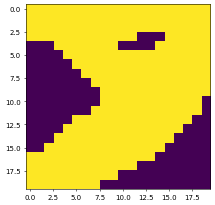

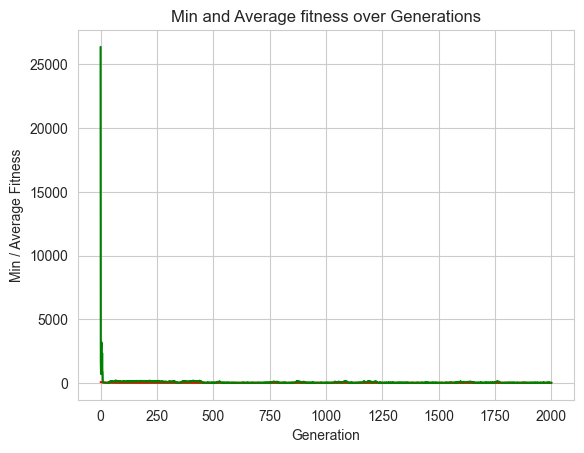

In [32]:
start = time.time()
top_ = main()
end = time.time() 

### RL model

In [33]:
class Model:
    def __init__(self, x):
        self.flag_ = True
        self.n, self.m = x.shape
        self.actions_dic={} 
    
        k=0
        for i in range(self.n):
            for j in range(self.m):
                self.actions_dic[k]=(i,j)
                k+=1
        
    def action_space_(self, action, X):
        x,y=self.actions_dic[action]
        X[x][y]=1

In [34]:
class CantileverEnv(gymnasium.Env):
    
    metadata = {"render.modes": ["human"]}

    def __init__(self,x1,y1):
        super().__init__()
        self.x0=x1
        self.y0=y1
        
        DIM =  self.x0 * self.y0
        N_DISCRETE_ACTIONS = self.x0 * self.y0
        
        self.action_space = spaces.Discrete(N_DISCRETE_ACTIONS)
        self.observation_space = spaces.Box(low=np.array([-1e10 for x in range(DIM)]),
                                            high=np.array([1e10 for y in range(DIM)]),
                                            shape=(DIM,),
                                           dtype=np.float64)
        
        self.x = np.ones(( self.x0, self.y0))*1e-04
    
        self.M=Model(self.x)
        
        self.reward=0
        self.step_=0
        self.needs_reset = True
        self.ext_reward=0

        
    def step(self, action):
        
        self.M.action_space_(action, self.x)        
        self.step_+=1
               
        done=False
                  
        if self.step_ > 0.8 * self.x0 * self.y0:                    # to tune 
            done=True            
            
        if self.needs_reset:
            raise RuntimeError("Tried to step environment that needs reset")
            
        if done:
            self.needs_reset = True
                         
        
        return self.x.reshape(self.x.shape[0]*self.x.shape[1]), self.ext_reward, done, False, dict()

    def reset(self, seed=0):
                   
        self.x = np.ones((self.x0, self.y0))*1e-04

        self.reward=0
        self.needs_reset = False
        self.step_=0
        self.ext_reward=0

        return self.x.reshape(self.x.shape[0]*self.x.shape[1]),{}

    def render(self, mode="human"):
        pass   

    def close(self):
        pass

In [35]:
class SaveOnBestTrainingRewardCallback(BaseCallback):
    """
    Callback for saving a model (the check is done every ``check_freq`` steps)
    based on the training reward (in practice, we recommend using ``EvalCallback``).

    :param check_freq: (int)
    :param log_dir: (str) Path to the folder where the model will be saved.
      It must contains the file created by the ``Monitor`` wrapper.
    :param verbose: (int)
    """

    def __init__(self, check_freq: int, log_dir: str, verbose=1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.log_dir = log_dir
        self.save_path = os.path.join(log_dir, "best_model")
        self.best_mean_reward = -np.inf

    def _init_callback(self) -> None:
        # Create folder if needed
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:
            
            
            
            # Retrieve training reward
            x, y = ts2xy(load_results(self.log_dir), "timesteps")

            if len(x) > 0:
                # Mean training reward over the last 100 episodes
                
                mean_reward = np.mean(y[-100:])
                
                if self.verbose > 0:
                    print(f"Num timesteps: {self.num_timesteps}")
                    print(
                        f"Best mean reward: {self.best_mean_reward:.2f} - Last mean reward per episode: {mean_reward:.2f}"
                    )

                # New best model, you could save the agent here
                if mean_reward > self.best_mean_reward:
                    self.best_mean_reward = mean_reward
                    # Example for saving best model
                    if self.verbose > 0:
                        print(f"Saving new best model to {self.save_path}.zip")
                    self.model.save(self.save_path)

        return True

In [36]:
def reconstruct_3d_structure(xy_plane, yz_plane, xz_plane):
    """
    Reconstructs a 3D structure from three 2D projections using extrusion and intersection.

    Parameters:
        xy_plane (ndarray): 2D binary array (X by Y) projection in XY plane.
        yz_plane (ndarray): 2D binary array (Y by Z) projection in YZ plane.
        xz_plane (ndarray): 2D binary array (X by Z) projection in XZ plane.

    Returns:
        volume (ndarray): 3D binary array (X by Y by Z) representing the reconstructed structure.
    """
    x_dim, y_dim = xy_plane.shape
    y_dim2, z_dim = yz_plane.shape
    x_dim2, z_dim2 = xz_plane.shape

    assert x_dim == x_dim2, "X dimensions mismatch between XY and XZ planes."
    assert y_dim == y_dim2, "Y dimensions mismatch between XY and YZ planes."
    assert z_dim == z_dim2, "Z dimensions mismatch between YZ and XZ planes."

    # Extrude XY along Z
    xy_extruded = np.repeat(xy_plane[:, :, np.newaxis], z_dim, axis=2)

    # Extrude YZ along X
    yz_extruded = np.repeat(yz_plane[np.newaxis, :, :], x_dim, axis=0)

    # Extrude XZ along Y
    xz_extruded = np.repeat(xz_plane[:, np.newaxis, :], y_dim, axis=1)

    # Intersect all three extrusions
    volume = xy_extruded & yz_extruded & xz_extruded

    return volume.astype(np.uint8)  # or bool, depending on your needs

In [37]:
def deconstruct(grid, topology, location):
    gr = grid.copy()
#     print(np.sum(gr))
    row_offset = (location // 4) * (x0//4)
    col_offset = (location % 4) * (x0//4)
    gr[row_offset:row_offset+x0//4, col_offset:col_offset+x0//4] = topology.copy()
#     gr[col_offset:col_offset+x0//4, row_offset:row_offset+x0//4] = topology.copy()
    return gr

In [38]:
def count_islands_dfs(grid):
    """
    Calculates the number of islands in a 2D binary grid using Depth First Search (DFS).

    An island is formed by connected 1's (horizontally/vertically adjacent).
    
    Args:
        grid (list of lists): A 2D matrix with values 0 or 1.

    Returns:
        int: The total number of islands found.
    """
#     if not grid or not grid[0]:
#         return 0
    
    rows = len(grid)
    cols = len(grid[0])
    visited = set()
    island_count = 0

    def dfs(r, c):
        """Helper function to traverse and mark a single island as visited."""
        # Check boundary conditions and if the cell has already been visited or is water (0)
        if r < 0 or r >= rows or c < 0 or c >= cols or grid[r][c] == 0 or (r, c) in visited:
            return
        
        visited.add((r, c))
        
        # Recursively visit all adjacent cells (up, down, left, right)
        dfs(r + 1, c) # Down
        dfs(r - 1, c) # Up
        dfs(r, c + 1) # Right
        dfs(r, c - 1) # Left

    # Iterate through every cell in the grid
    for r in range(rows):
        for c in range(cols):
            # If we find land (1) that hasn't been visited yet, 
            # it means we've found the start of a new island.
            if grid[r][c] == 1 and (r, c) not in visited:
                island_count += 1
                # Start DFS from this point to mark all parts of this island
                dfs(r, c)
                
    return island_count

In [39]:
def calculate_smoothness_metric(binary_matrix):
    """
    Calculates a smoothness metric for a 2D binary matrix.
    Lower values indicate greater smoothness. A value of 0 means 
    the image is perfectly uniform or has only linear transitions.

    The metric is the sum of differences between a pixel and its
    right and bottom neighbors, effectively counting vertical and
    horizontal edges.

    Args:
        binary_matrix (list of lists or numpy array): A 2D matrix 
                                                     with values 0 or 1.

    Returns:
        int: The total count of horizontal and vertical transitions.
    """
    # Convert to a numpy array for efficient processing
    matrix = np.array(binary_matrix, dtype=int)
    h, w = matrix.shape
    
    # Calculate absolute differences for horizontal transitions
    # We slice the matrix to compare each element with its right neighbor
    horizontal_diffs = np.abs(matrix[:, :w-1] - matrix[:, 1:])
    
    # Calculate absolute differences for vertical transitions
    # We slice the matrix to compare each element with its bottom neighbor
    vertical_diffs = np.abs(matrix[:h-1, :] - matrix[1:, :])
    
    # The sum of these differences gives the total number of transitions (edges)
    total_transitions = np.sum(horizontal_diffs) + np.sum(vertical_diffs)
    
    return int(total_transitions)

In [40]:
class CrossRewardEnv(gymnasium.Env):
    def __init__(self):
        super().__init__()
        self.env0 = CantileverEnv(x0//4,y0//4)
        self.env1 = CantileverEnv(x0//4,y0//4)
        self.env2 = CantileverEnv(x0//4,y0//4)
        self.env3 = CantileverEnv(x0//4,y0//4)
        self.env4 = CantileverEnv(x0//4,y0//4)
        self.env5 = CantileverEnv(x0//4,y0//4)
        self.env6 = CantileverEnv(x0//4,y0//4)
        self.env7 = CantileverEnv(x0//4,y0//4)
        self.env8 = CantileverEnv(x0//4,y0//4)
        self.env9 = CantileverEnv(x0//4,y0//4)
        self.env10 = CantileverEnv(x0//4,y0//4)
        self.env11 = CantileverEnv(x0//4,y0//4)
        self.env12 = CantileverEnv(x0//4,y0//4)
        self.env13 = CantileverEnv(x0//4,y0//4)
        self.env14 = CantileverEnv(x0//4,y0//4)
        self.env15 = CantileverEnv(x0//4,y0//4)

        self.observation_space = spaces.Dict({
            'plane0': self.env0.observation_space,
            'plane1': self.env1.observation_space,
            'plane2': self.env2.observation_space,
            'plane3': self.env3.observation_space,
            'plane4': self.env4.observation_space,
            'plane5': self.env5.observation_space,
            'plane6': self.env6.observation_space,
            'plane7': self.env7.observation_space,
            'plane8': self.env8.observation_space,
            'plane9': self.env9.observation_space,
            'plane10': self.env10.observation_space,
            'plane11': self.env11.observation_space,
            'plane12': self.env12.observation_space,
            'plane13': self.env13.observation_space,
            'plane14': self.env14.observation_space,
            'plane15': self.env15.observation_space,
        })

        self.action_space = spaces.MultiDiscrete([(x0*y0)//16 for i in range(16)])
        self.step1_ = 0
        self.grid = np.where( top_ == 0, 1e-04, top_)       # transpose ?
        self.grid1 = np.where( top_ == 0, 1e-04, top_) 

    def reset(self, seed=0):
        obs0, info0 = self.env0.reset()
        obs1, info1 = self.env1.reset()
        obs2, info2 = self.env2.reset()
        obs3, info3 = self.env3.reset()
        obs4, info4 = self.env4.reset()
        obs5, info5 = self.env5.reset()
        obs6, info6 = self.env6.reset()
        obs7, info7 = self.env7.reset()
        obs8, info8 = self.env8.reset()
        obs9, info9 = self.env9.reset()
        obs10, info10 = self.env10.reset()
        obs11, info11 = self.env11.reset()
        obs12, info12 = self.env12.reset()
        obs13, info13 = self.env13.reset()
        obs14, info14 = self.env14.reset()
        obs15, info15 = self.env15.reset()
        self.step1_=0
        self.grid1 = np.where( top_ == 0, 1e-04, top_) 
#         self.grid = top_.copy()  # transpose ?
        return {
            'plane0': obs0,
            'plane1': obs1,
            'plane2': obs2,
            'plane3': obs3,
            'plane4': obs4,
            'plane5': obs5,
            'plane6': obs6,
            'plane7': obs7,
            'plane8': obs8,
            'plane9': obs9,
            'plane10': obs10,
            'plane11': obs11,
            'plane12': obs12,
            'plane13': obs13,
            'plane14': obs14,
            'plane15': obs15,
        }, {
            'plane0': info0,
            'plane1': info1,
            'plane2': info2,
            'plane3': info3,
            'plane4': info4,
            'plane5': info5,
            'plane6': info6,
            'plane7': info7,
            'plane8': info8,
            'plane9': info9,
            'plane10': info10,
            'plane11': info11,
            'plane12': info12,
            'plane13': info13,
            'plane14': info14,
            'plane15': info15,
        }

    def step(self, action):
        a0 = action[0]
        a1 = action[1]
        a2 = action[2]
        a3 = action[3]
        a4 = action[4]
        a5 = action[5]
        a6 = action[6]
        a7 = action[7]
        a8 = action[8]
        a9 = action[9]
        a10 = action[10]
        a11 = action[11]
        a12 = action[12]
        a13 = action[13]
        a14 = action[14]
        a15 = action[15]
        
        
        obs0, r0, done0,_, info0 = self.env0.step(a0)
        obs1, r1, done1,_, info1 = self.env1.step(a1)
        obs2, r2, done2,_, info2 = self.env2.step(a2)
        obs3, r3, done3,_, info3 = self.env3.step(a3)
        obs4, r4, done4,_, info4 = self.env4.step(a4)
        obs5, r5, done5,_, info5 = self.env5.step(a5)
        obs6, r6, done6,_, info6 = self.env6.step(a6)
        obs7, r7, done7,_, info7 = self.env7.step(a7)
        obs8, r8, done8,_, info8 = self.env8.step(a8)
        obs9, r9, done9,_, info9 = self.env9.step(a9)
        obs10, r10, done10,_, info10 = self.env10.step(a10)
        obs11, r11, done11,_, info11 = self.env11.step(a11)
        obs12, r12, done12,_, info12 = self.env12.step(a12)
        obs13, r13, done13,_, info13 = self.env13.step(a13)
        obs14, r14, done14,_, info14 = self.env14.step(a14)
        obs15, r15, done15,_, info15 = self.env15.step(a15)
       
        OBS=[obs0,obs1,obs2,obs3,obs4,obs5,obs6,obs7,obs8,obs9,obs10,obs11,obs12,obs13,obs14,obs15]    
        envs = [self.env0,
             self.env1,
             self.env2,
             self.env3,
             self.env4,
             self.env5,
             self.env6,
             self.env7,
             self.env8,
             self.env9,
             self.env10,
             self.env11,
             self.env12,
             self.env13,
             self.env14,
             self.env15,
            ] 
        
        CO=[]
        for i in range(len(OBS)):       
            gr = deconstruct(self.grid, OBS[i].reshape(x0//4,y0//4), i)
            self.grid1 = deconstruct(self.grid1, OBS[i].reshape(x0//4,y0//4), i)
            constI=np.sum(gr)/(x0*y0)
            CO.append(constI)
            if constI > 0.65:                    # to tune 
                self.args = get_args(*mbb_beam(rd=0))
                self.tmp, self.const = fast_stopt(self.args, gr)
                reward = 1/self.tmp + 1/calculate_smoothness_metric(gr.reshape(x0, y0))
                if count_islands_dfs(gr) == 1:
                    reward *= 10  
                envs[i].ext_reward = reward     
            else:
                envs[i].ext_reward = 0
                            
        self.step1_+=1
        
        Do=(np.mean(CO)>0.67)
        done = (done0 or done1 or done2 or done3 or done4 or done5 or done6 or
        done7 or done8 or done9 or done10 or done11 or done12 or done13 or done14 or done15 or bool(Do))
        
        args1 = get_args(*mbb_beam(rd=0))
        tmp1, const1 = fast_stopt(args1, self.grid1)
        REW = 1/tmp1 + 1/calculate_smoothness_metric(self.grid1.reshape(x0, y0))
        if count_islands_dfs(self.grid1) == 1:
            REW *= 10
            
        return {
            'plane0': obs0,
            'plane1': obs1,
            'plane2': obs2,
            'plane3': obs3,
            'plane4': obs4,
            'plane5': obs5,
            'plane6': obs6,
            'plane7': obs7,
            'plane8': obs8,
            'plane9': obs9,
            'plane10': obs10,
            'plane11': obs11,
            'plane12': obs12,
            'plane13': obs13,
            'plane14': obs14,
            'plane15': obs15,
        },  REW, done, False, {
            'plane0': info0,
            'plane1': info1,
            'plane2': info2,
            'plane3': info3,
            'plane4': info4,
            'plane5': info5,
            'plane6': info6,
            'plane7': info7,
            'plane8': info8,
            'plane9': info9,
            'plane10': info10,
            'plane11': info11,
            'plane12': info12,
            'plane13': info13,
            'plane14': info14,
            'plane15': info15,
        }

    def render(self, mode='human'):    
        pass

    def close(self):
        self.env0.close()
        self.env1.close()
        self.env2.close()
        self.env3.close()
        self.env4.close()
        self.env5.close()
        self.env6.close()
        self.env7.close()
        self.env8.close()
        self.env9.close()
        self.env10.close()
        self.env11.close()
        self.env12.close()
        self.env13.close()
        self.env14.close()
        self.env15.close()

### Training 

In [41]:
ts = 0.5e6

In [42]:
# Create log dir
log_dir = "/tmp/gym7_v3aleof1qaz/"
os.makedirs(log_dir, exist_ok=True)

In [43]:
callback = SaveOnBestTrainingRewardCallback(check_freq = 50_000, log_dir=log_dir)

In [44]:
env=CrossRewardEnv()
check_env(env)
env  = Monitor(env, log_dir)

In [ ]:
start = time.time()
model = PPO("MultiInputPolicy", env).learn(total_timesteps=ts, callback=callback)
end = time.time()  

Num timesteps: 50000
Best mean reward: -inf - Last mean reward per episode: 0.57
Saving new best model to /tmp/gym7_v3aleof1qaz/best_model.zip
Num timesteps: 100000
Best mean reward: 0.57 - Last mean reward per episode: 1.52
Saving new best model to /tmp/gym7_v3aleof1qaz/best_model.zip


In [ ]:
print('Total time taken: {} min'.format((end - start)/60))

### Inference

In [ ]:
def construct(OBS):
    grid = np.zeros((x0, y0), dtype=int)
    for i in range(len(OBS)):
        row_offset = (i // 4) * (x0//4)
        col_offset = (i % 4) * (x0//4)
#         print(row_offset,row_offset+x0//4, col_offset,col_offset+x0//4)
#         print(OBS[i])
        grid[row_offset:row_offset+x0//4, col_offset:col_offset+x0//4] = OBS[i].copy()
#         grid[col_offset:col_offset+x0//4, row_offset:row_offset+x0//4] = OBS[i].copy()

    return grid 

In [ ]:
obs = env.reset()

In [ ]:
obs = obs[0]

In [ ]:
i=0
ans=[]
while i < 1000:
    action, _states = model.predict(obs)
    obs, rewards, dones, _, info = env.step(action)
    ans.append(obs)
    if dones:
        break
    i+=1

In [ ]:
OBS=[ans[-1]['plane0'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane1'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane2'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane3'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane4'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane5'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane6'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane7'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane8'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane9'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane10'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane11'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane12'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane13'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane14'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane15'].astype(np.uint8).reshape(x0//4,y0//4)]


grid = construct(OBS)

In [ ]:
draw(grid)

In [ ]:
results_plotter.plot_results([log_dir], ts, results_plotter.X_TIMESTEPS, "CantileverEnv")

In [ ]:
obs = env.reset()

In [ ]:
obs = obs[0]

In [ ]:
model_best = PPO.load(log_dir + "best_model.zip", env = env)

In [ ]:
i=0
ans=[]
while i<1000:
    action, _states = model_best.predict(obs)
    obs, rewards, dones, _ , info = env.step(action)
    ans.append(obs)
    if dones:
        break
    
    i+=1

In [ ]:
OBS=[ans[-1]['plane0'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane1'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane2'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane3'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane4'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane5'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane6'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane7'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane8'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane9'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane10'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane11'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane12'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane13'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane14'].astype(np.uint8).reshape(x0//4,y0//4),
     ans[-1]['plane15'].astype(np.uint8).reshape(x0//4,y0//4)]


grid = construct(OBS)

In [ ]:
draw(grid)

In [ ]:
args = get_args(*mbb_beam(rd=0))
tmp, const = fast_stopt(args, grid.astype(float))

In [ ]:
tmp

In [ ]:
const

In [ ]:
grid

In [ ]:
arr = grid

In [ ]:
# 1. Convert Matrix to Point Cloud
# np.argwhere finds indices where value is 1
points = np.argwhere(arr == 1)

# 2. Build the Alpha Complex
# This reconstructs the topological structure from the discrete points
alpha_complex = gd.AlphaComplex(points=points)
simplex_tree = alpha_complex.create_simplex_tree()

# 3. Visualization
plt.figure(figsize=(5, 5))

# Plot the original matrix points
plt.scatter(points[:, 1], points[:, 0], c='red', label='Matrix Points (1s)')

# Reconstruct and plot the edges (1-simplices)
# Adjust alpha_threshold to "connect" points at different distances
alpha_threshold = 3
for simplex, filtration in simplex_tree.get_skeleton(1):
    if len(simplex) == 2 and filtration < alpha_threshold:
        p1, p2 = points[simplex[0]], points[simplex[1]]
        # Note: argwhere returns (row, col), so we plot (col, row) for (x, y)
        plt.plot([p1[1], p2[1]], [p1[0], p2[0]], 'b-', alpha=0.6)

plt.gca().invert_yaxis() # Match matrix coordinate system (top-down)
plt.title("Topology Reconstructed from Binary Matrix")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# 4. Extract Topological Invariants
persistence = simplex_tree.persistence()
print("Topological Features found:")
for dim, (birth, death) in persistence:
    feature_type = "Component" if dim == 0 else "Hole/Loop"
    print(f"{feature_type} exists from radius {birth} to {death}")